# 02 — Preprocessing, Batching, and the Production Data Contract (TensorFlow / Keras)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


Raw MNIST pixels are integers in `[0,255]`; this ANN consumes `float32` values in `[0,1]` and flattens 28×28 into 784 features. The same transformation must be used in training, validation, test and production inference. A preprocessing mismatch is a form of train/serve skew.

For a batch size $B$, the input is $X\in\mathbb{R}^{B\times784}$ and labels have shape `(B,)`. Mini-batching trades gradient noise, memory usage and throughput.


## Code walkthrough — verify scale, dtype and batch shapes
The cell reuses the canonical split function. Then it prints the exact dtype/range and constructs one shuffled mini-batch using the branch's native data pipeline. Shuffling is enabled only for training; validation/test order is irrelevant to learning and should remain deterministic.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42)
from pathlib import Path
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


X_train, y_train, X_val, y_val, X_test, y_test = prepare_splits()
print("dtype:", X_train.dtype)
print("pixel min/max:", X_train.min(), X_train.max())
print("one image vector shape:", X_train[0].shape)
print("batch example:", X_train[:32].shape, y_train[:32].shape)
ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(5000, seed=SEED)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
xb, yb = next(iter(ds))
print("tf.data batch:", xb.shape, yb.shape, xb.dtype, yb.dtype)

2026-09-07 18:54:35.835139: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


dtype: float32
pixel min/max: 0.0 1.0
one image vector shape: (784,)
batch example: (32, 784) (32,)
tf.data batch: (32, 784) (32,) <dtype: 'float32'> <dtype: 'uint8'>


## Code walkthrough — visualize normalization instead of trusting it
Histograms reveal whether preprocessing unexpectedly collapsed or shifted the pixel distribution. In enterprise data, the analogous contract should include schema, units, categories, null policy, clipping, vocabulary/tokenization and feature version.


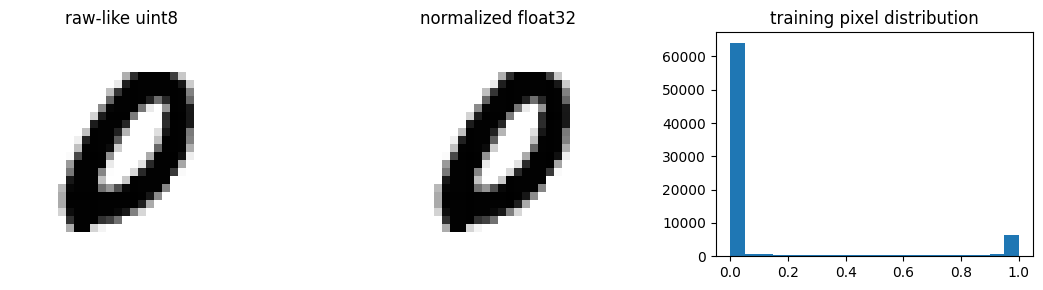

In [2]:
sample_raw = (X_train[0].reshape(28, 28) * 255).astype("uint8")
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
axes[0].imshow(sample_raw, cmap="gray_r")
axes[0].set_title("raw-like uint8")
axes[0].axis("off")
axes[1].imshow(X_train[0].reshape(28, 28), cmap="gray_r")
axes[1].set_title("normalized float32")
axes[1].axis("off")
axes[2].hist(X_train.ravel()[::50], bins=20)
axes[2].set_title("training pixel distribution")
plt.tight_layout()
plt.show()

## Business implication
When a production pipeline changes image scaling, transaction units, category encoding or text normalization without changing the model, predictions can degrade even though the model artifact is untouched. Treat preprocessing as versioned model logic.
